In [10]:
import numpy as np
import scipy
from Scripts.Optimization.optimization import Optimizer
from Scripts.Finite_Elements.Beam_FEA_System.beam_type import BeamType
from Scripts.Finite_Elements.Beam_FEA_System.beam_system import BeamSystem
from Scripts.Finite_Elements.material_properties import Materials


In [11]:
opt = Optimizer()
opt.independent_properties_calc()

opt.active_constraints = {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
}

opt.design_variables_initial_guess = {
    "arm_diameter": 50,
    "arm_thickness": 25,
    "strut_diameter": 50,
    "strut_thickness": 25,
    "strut_distance": 510,
    "hub_radius": 300,
    "hub_flange_thickness": 10,
    "hub_web_thickness": 10
}

res = opt.run_opt()

x = np.array(res.x) * np.array(list(opt.design_variables_multipliers.values()))

cons_res_opt, cons_labels_opt = opt.test_results(x)

cons_res_int, cons_labels_int = opt.test_results(list(opt.design_variables_initial_guess.values()))

dv_keys = list(opt.design_variables_initial_guess.keys())

print("===== INITIAL GUESS =====")

print("design variables")
for i in range(len(dv_keys)):
    print(f"   {dv_keys[i]}: {list(opt.design_variables_initial_guess.values())[i]}")

print("constraints")
for i in range(len(cons_res_int)):
    print(f"   {cons_labels_int[i]}: {cons_res_int[i]}")

print(f"mass w/ payload: {opt.mass(opt.design_variables_initial_guess) * 1000} kg")

print("===== Optimized =====")
print("design variables")
for i in range(len(dv_keys)):
    print(f"   {dv_keys[i]}: {x[i]}")

print("constraints")
for i in range(len(cons_res_opt)):
    print(f"   {cons_labels_opt[i]}: {cons_res_opt[i]}")

print(f"mass w/ payload: {res.fun * 1000} kg")

print("OPT_OUTPUT")
opt.test_results(x, detailed_output=True)

print("Initial guess opt actual:")
print(res.x)


Optimization terminated successfully
===== INITIAL GUESS =====
design variables
   arm_diameter: 50
   arm_thickness: 25
   strut_diameter: 50
   strut_thickness: 25
   strut_distance: 510
   hub_radius: 300
   hub_flange_thickness: 10
   hub_web_thickness: 10
constraints
   deflection: 0.035933515322048803
   stress: 0.04297201825059047
   frequency: 0.4389833463008683
   energy: 0.5109356371935025
   damage: 0.0
mass w/ payload: 34.8513169929545 kg
===== Optimized =====
design variables
   arm_diameter: 50.0
   arm_thickness: 0.3190490915982662
   strut_diameter: 50.0
   strut_thickness: 0.3596399172851465
   strut_distance: 501.3303426354724
   hub_radius: 100.0
   hub_flange_thickness: 0.7
   hub_web_thickness: 0.7
constraints
   deflection: 0.9999999999999253
   stress: 0.9562445411185154
   frequency: 0.26813051492306533
   energy: 0.32606730649499127
   damage: 0.0
mass w/ payload: 0.8270922461865914 kg
OPT_OUTPUT
=== Optimizer Results ===
Wingspan: 1127.3025260953375 mm
Force: 

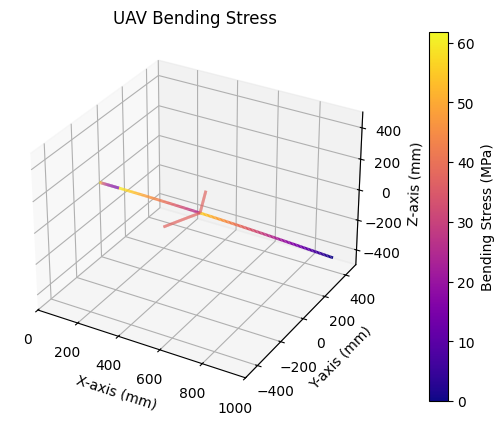

In [13]:
from Scripts.visualization import drone_geometry_stress

drone_geometry_stress(opt.fea, 1, 100)

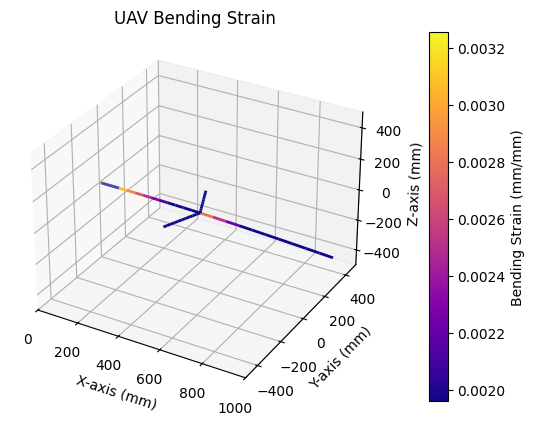

In [12]:
from Scripts.visualization import drone_geometry_strain

drone_geometry_strain(opt.fea, 1, 100)

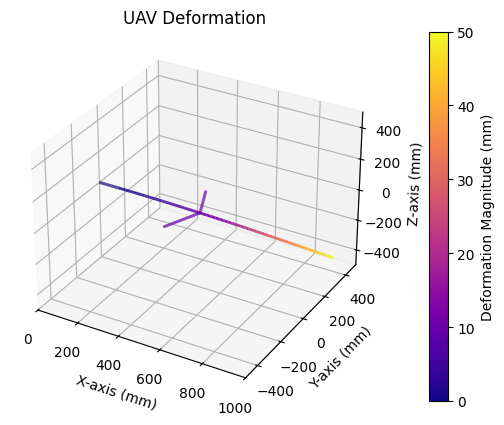

In [14]:
from Scripts.visualization import drone_geometry_deformation

drone_geometry_deformation(opt.fea, 1, 100)

In [19]:
import Scripts.unit_conversions as uc
opt.fea.beam_system.solve_natural_frequencies()
print(f"First Nf: {opt.fea.beam_system.natural_frequencies[0] * uc.rad_per_s_to_Hz} Hz")
print(f"Second Nf: {opt.fea.beam_system.natural_frequencies[1] * uc.rad_per_s_to_Hz} Hz")

First Nf: 23.521227245692888 Hz
Second Nf: 54.56485130792905 Hz


In [21]:
print(352.7148774623214 * uc.rad_per_s_to_Hz)

print(max(opt.fea.beam_system.mag_displacements_amplitude))

56.1363162501806
20.109788619228397


In [ ]:
# plot the space

